# Digits Classification with Multinomial Naive Bayes

In this notebook, we build a **Multinomial Naive Bayes** classifier to recognize handwritten digits (0–9), using the built-in `load_digits` dataset from scikit-learn.

## Libraries

In [1]:
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix ,classification_report , accuracy_score

## Load Dataset

In [2]:
df=load_digits()

In [3]:
X=df.data

In [4]:
y=df.target

## Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42
)

## Model Training

In [6]:
MultinomialNBModel = MultinomialNB(alpha=1.0)

In [7]:
MultinomialNBModel.fit(X_train,y_train)

MultinomialNB()

In [8]:
y_train_pred = MultinomialNBModel.predict(X_train)
y_test_pred = MultinomialNBModel.predict(X_test)

## Evaluate

In [9]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'{train_accuracy:.2f} , {test_accuracy:.2f}')

0.91 , 0.91


In [10]:
print(classification_report(y_train, y_train_pred), '\n', classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       145
           1       0.87      0.75      0.81       154
           2       0.91      0.89      0.90       144
           3       0.99      0.87      0.92       149
           4       0.97      0.95      0.96       135
           5       0.97      0.87      0.92       135
           6       0.97      0.98      0.98       146
           7       0.88      0.99      0.94       145
           8       0.78      0.90      0.83       144
           9       0.77      0.88      0.82       140

    accuracy                           0.91      1437
   macro avg       0.91      0.91      0.91      1437
weighted avg       0.91      0.91      0.91      1437
 
               precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.87      0.71      0.78        28
           2       0.86      0.94      0.90        33
           3       1.0

In [11]:
train_accuracy = MultinomialNBModel.score(X_train, y_train)
test_accuracy = MultinomialNBModel.score(X_test, y_test)

train_accuracy, test_accuracy

(0.9053583855254002, 0.9111111111111111)

## Confusion Matrix

Text(50.722222222222214, 0.5, 'Actual')

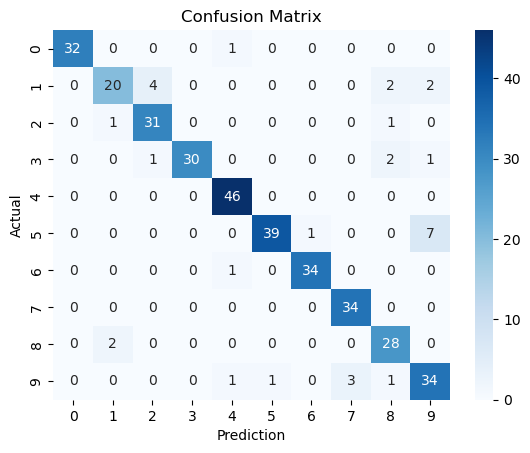

In [12]:
CM = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    CM,
    annot=True,
    cmap='Blues',
    xticklabels=df.target_names, yticklabels=df.target_names
)
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')

## Conclusion

The Multinomial Naive Bayes model achieves **91% accuracy on both the training and test sets**, with generally strong precision and recall across most digit classes. Digits **1**, **8**, and **9** show relatively lower precision/recall than the rest, meaning the model confuses them with each other more often (a common pattern in handwritten digit recognition, since these digits can look visually similar).